In [62]:
from pandas_datareader import data as pdr
import yfinance as yf

In [63]:
symbol = "AMZN"
start = "2020-9-01"
end = "2024-10-01"

df = yf.download(symbol, start, end)

[*********************100%***********************]  1 of 1 completed


In [64]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(df["Close"].values.reshape(-1, 1))

In [65]:
import numpy as np
# Create a dataset with lagged values as features

def create_dataset(data, lag=1):
    X, y = [], []
    for i in range(len(data) - lag - 1):
        X.append(data[i:(i + lag), 0])
        y.append(data[i + lag, 0])
    return np.array(X), np.array(y)

In [66]:
# lag : 지연값
lag = 5
X, y = create_dataset(scaled_close, lag)

In [67]:
# Split the data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [68]:
from xgboost import XGBRegressor

# Train the XGBRegressor model
xgb_model = XGBRegressor(objective='reg:squarederror',
                     n_estimators=100,
                     tree_method='auto',
                     )
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [69]:
# 주식 가격 예측
predicted_stock_price = xgb_model.predict(X_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price.reshape(-1, 1))

In [70]:
# 정규화된 테스트 데이터를 역변환
real_stock_price = scaler.inverse_transform(y_test.reshape(-1, 1))

In [77]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Calculate the root mean squared error (RMSE)
rmse = sqrt(mean_squared_error(real_stock_price, predicted_stock_price))
print("RMSE: ", rmse)

RMSE:  5.066555292361199


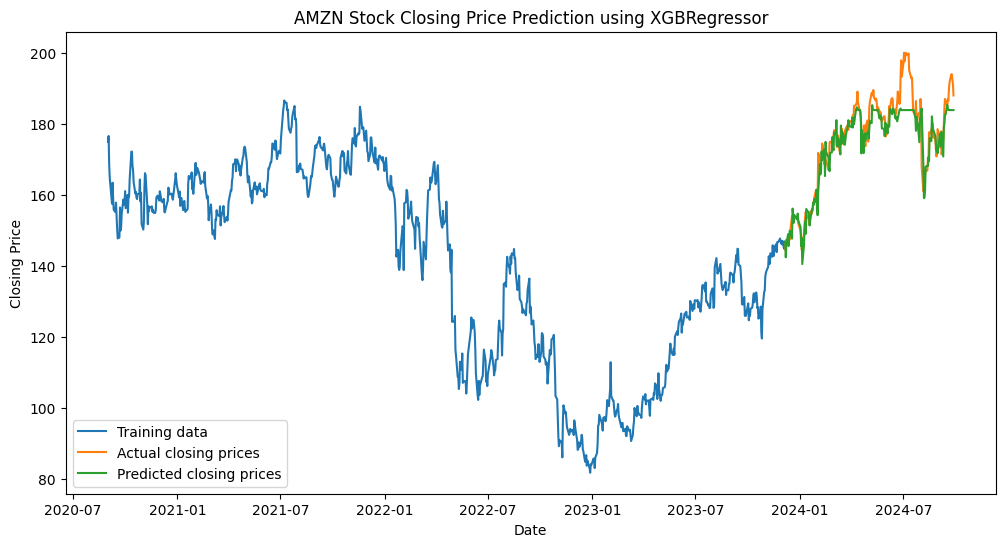

In [72]:
import matplotlib.pyplot as plt

# Plot the actual vs. predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(df["Close"].index[:train_size + lag], df["Close"][:train_size + lag], label="Training data")
plt.plot(df["Close"].index[train_size + lag:train_size + lag + len(predicted_stock_price)], df["Close"][train_size + lag:train_size + lag + len(predicted_stock_price)], label="Actual closing prices")
plt.plot(df["Close"].index[train_size + lag:train_size + lag + len(predicted_stock_price)], predicted_stock_price, label="Predicted closing prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title(f"{symbol} Stock Closing Price Prediction using XGBRegressor")
plt.legend()
plt.show()

In [73]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-09-01,174.479004,175.693497,173.350006,174.955994,174.955994,68644000
2020-09-02,177.350006,177.612503,174.334503,176.572495,176.572495,78630000
2020-09-03,174.250000,174.420502,165.149994,168.399994,168.399994,163222000
2020-09-04,165.899994,169.074997,155.556503,164.731003,164.731003,175636000
2020-09-08,157.199997,162.542496,156.500000,157.492004,157.492004,121884000
...,...,...,...,...,...,...
2024-09-24,194.270004,195.369995,190.130005,193.960007,193.960007,43478900
2024-09-25,193.750000,193.949997,192.160004,192.529999,192.529999,26391100
2024-09-26,194.309998,194.529999,189.539993,191.160004,191.160004,36334900


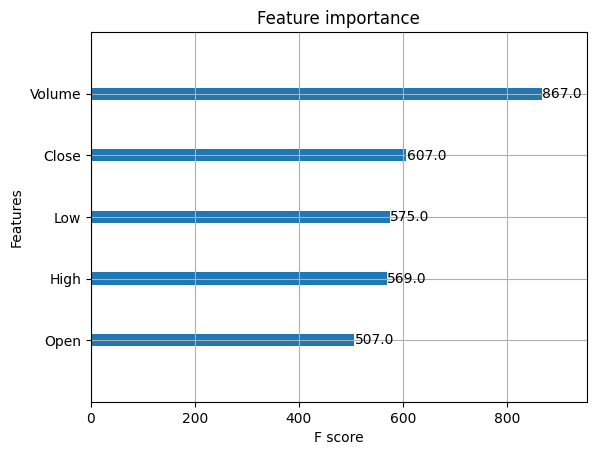

In [79]:
from xgboost import plot_importance

# 피처 중요도 시각화
plot_importance(xgb_model).set_yticklabels(["Open", "High", "Low", "Close","Volume"])
plt.show()      